# Procesamiento de Imágenes. Cuaderno de práctica 1
## La imagen digital

**Universidad Diego Portales. Escuela de Ingeniería Informática y Telecomunicaciones**

En este cuaderno se practican los contenidos de la clase *La imagen digital*:

1. Lectura de imágenes con OpenCV
2. La imagen como arreglo de números: `uint8`
3. La imagen a color: BGR vs. RGB
4. Separación y recomposición de canales
5. Distribución de intensidad: histogramas
6. Conversión a escala de grises (¿por qué no basta con promediar?)
7. **Segmentación por color**: histograma + binarización de un canal
8. Ejercicios propuestos

**Cómo trabajar:** cada ejercicio tiene un enunciado en Markdown y una celda de código.
Ejecuten las celdas en orden, modifiquen los parámetros.

---
## 0. Preparación del entorno y de las imágenes

Trabajaremos con cuatro imágenes:

| Archivo | Contenido | Para qué la usamos |
|---|---|---|
| `gato.jpg` | foto de un gato | lectura, escala de grises, BGR/RGB |
| `gato_oscuro.jpg` | la misma foto, subexpuesta | comparación de histogramas |
| `loros.jpg` | ocho loros de colores (A–H) | separación de canales |
| `ecuador2006.jpg` | escena de fútbol (amarillo, azul, rojo, verde) | canales, histogramas, segmentación |



In [1]:
# Librerías que usaremos en todo el cuaderno
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV:", cv2.__version__)
print("NumPy :", np.__version__)

OpenCV: 5.0.0
NumPy : 2.5.2


---
## 1. Lectura de una imagen con OpenCV (`cv2`)

`cv2.imread(ruta, flag)` lee una imagen desde el disco y devuelve un arreglo de NumPy.

* `flag = 0`,  escala de grises (arreglo **2D**)
* `flag = 1` (o sin flag), color (arreglo **3D**)

**Importante:** si la imagen no existe, `imread` **no lanza error**: devuelve `None`.
Por eso siempre conviene verificar.

### Ejercicio 1.1
Lean `gato.jpg` en escala de grises y muéstrenla con `plt.imshow` **sin** indicar el mapa de colores.

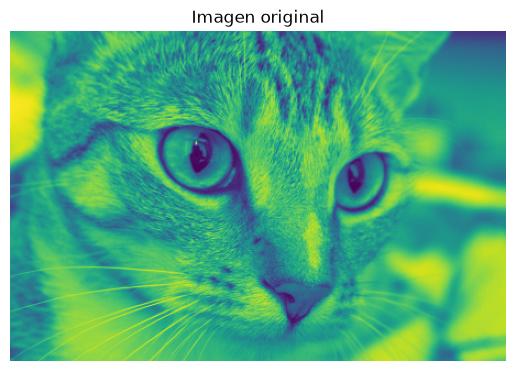

In [12]:
imagen = cv2.imread("gato.jpg" ,0)


plt.imshow(imagen)
plt.axis('off')
plt.title("Imagen original")
plt.show()

**Pregunta 1.1:** la imagen está en escala de grises, pero se ve amarilla y azul.
¿Por qué?

*(Respuesta: por defecto `matplotlib` aplica el mapa de colores `viridis`, que va de azul a
amarillo. La imagen no cambió, cambió solo su **visualización**.)*

### Ejercicio 1.2
Repitan la visualización indicando `cmap='gray'` y compárenla con otros mapas de colores.

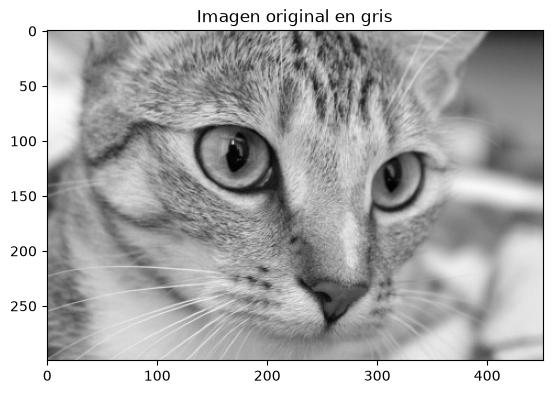

In [18]:
imagen = cv2.imread("gato.jpg" ,0)
plt.imshow(imagen, cmap='gray')
plt.title("Imagen original en gris")
plt.show()

### Ejercicio 1.3
Toda imagen es un arreglo. Averigüen sus propiedades básicas: dimensiones, tipo de dato,
valores mínimo y máximo, y cuánta memoria ocupa.

In [15]:
print("shape :", imagen.shape) # (filas, columnas) -> imagen 2D
print("dtype :", imagen.dtype) # uint8
print("min/max:", imagen.min(), imagen.max())
print("píxeles:", imagen.size)
print("memoria:", imagen.nbytes / 1024, "KB")

shape : (300, 451)
dtype : uint8
min/max: 3 194
píxeles: 135300
memoria: 132.12890625 KB


---
## 2. La imagen como arreglo de números: `uint8`

Una imagen en escala de grises es un **arreglo bidimensional** codificado normalmente en
**uint8** (*unsigned integer* de 8 bits): valores enteros de **0 (negro) a 255 (blanco)**.

### Ejercicio 2.1
Impriman un bloque de 6×6 píxeles y muéstrenlo ampliado para ver "los números detrás de la imagen".

[[122 122 119 119 117 112]
 [124 122 116 117 115 110]
 [129 124 120 118 114 109]
 [134 126 127 121 115 111]
 [122 123 125 122 114 112]
 [123 124 119 120 115 115]]


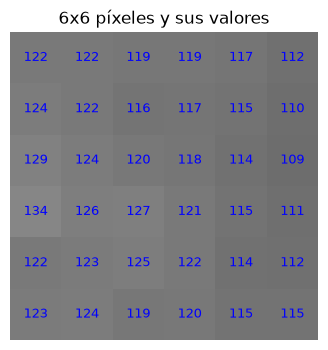

In [17]:
fila_0, fila_1 = 100, 106
columna_0, columna_1 = 150, 156

parche = imagen[fila_0:fila_1, columna_0:columna_1]
print(parche)

plt.figure(figsize=(4, 4))
plt.imshow(parche, cmap="gray", vmin=0, vmax=255)
for (f, c), v in np.ndenumerate(parche):
    plt.text(c, f, str(v), ha="center", va="center", color="blue", fontsize=9)

plt.title("6x6 píxeles y sus valores")
plt.axis("off")
plt.show()

### Ejercicio 2.2
Modifiquen la imagen directamente: pinten un cuadrado blanco (255) y una franja negra (0).
Trabajen **sobre una copia** para no alterar el original.

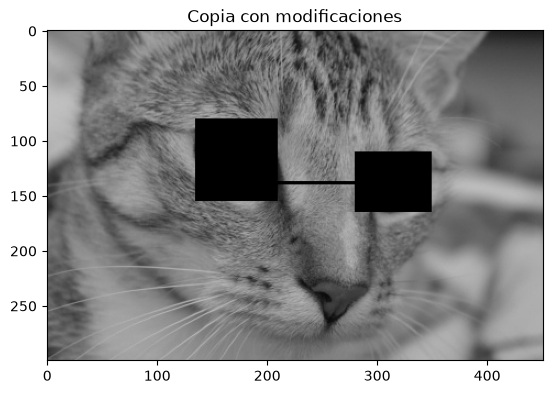

In [45]:
copia = imagen.copy()
copia[80:155 , 135:210] = 0
copia[110:165 , 280:350] = 0
copia[137:140 , 200:300] = 0

plt.imshow(copia, cmap="gray", vmin=0, vmax=255)
plt.title("Copia con modificaciones")
plt.show()

### Ejercicio 2.3 — NumPy **envuelve**, OpenCV **satura**

¿Qué pasa si a un `uint8` con valor 250 le sumamos 10? El resultado no cabe en 8 bits.
NumPy da la vuelta (250 + 10 = 4) mientras que OpenCV se queda en el tope (255).
Compruébenlo.

NumPy a + b = 4
OpenCV cv2.add = 255


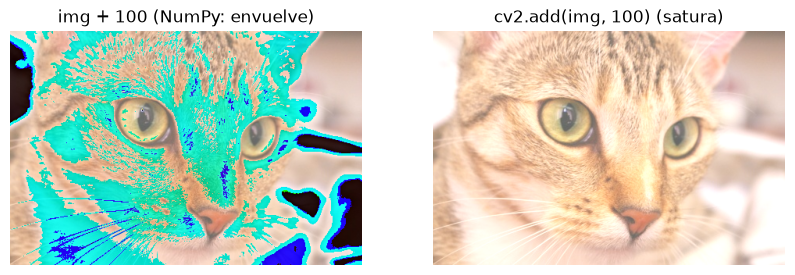

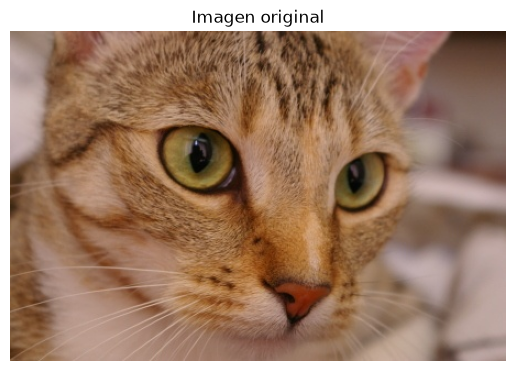

In [59]:
# Comparación de overflow: NumPy envuelve (wrap-around) mientras que OpenCV satura al sumar
# OpenCV trabaja con arreglos, así que definimos los números como imágenes de 1x1 píxel
a = np.array([[250]], dtype=np.uint8)
b = np.array([[10]], dtype=np.uint8)

print("NumPy a + b =", (a + b)[0, 0]) # envuelve: 4
print("OpenCV cv2.add =", cv2.add(a, b)[0, 0]) # satura: 255

# El mismo efecto sobre una imagen completa
suma_numpy = imagen + np.uint8(100)
suma_opencv = cv2.add(imagen, 100)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(suma_numpy, cmap="gray"); plt.title("img + 100 (NumPy: envuelve)");
plt.axis("off")

plt.subplot(1, 2, 2); plt.imshow(suma_opencv, cmap="gray"); plt.title("cv2.add(img, 100) (satura)");
plt.axis("off")
plt.show()
plt.imshow(imagen, cmap='gray'); plt.axis('off'); plt.title('Imagen original'); plt.show()

**Pregunta 2.3:** ¿a qué corresponden las manchas oscuras que aparecen en la imagen de
la izquierda? ¿En qué zonas de la imagen original ocurren?



---
## 3. La imagen a color: BGR vs. RGB

Una imagen a color es un arreglo de **tres dimensiones**: `(alto, ancho, canales)`.
Cada canal está codificado como una imagen en escala de grises (`uint8`), porque el
computador no "ve" color, solo **intensidad**.

**OpenCV lee las imágenes en orden BGR**, mientras que `matplotlib` espera **RGB**.

### Ejercicio 3.1
Lean `gato.jpg` a color y muéstrenla tal cual. Observen el resultado.

Text(0.5, 1.0, 'Imagen original a color')

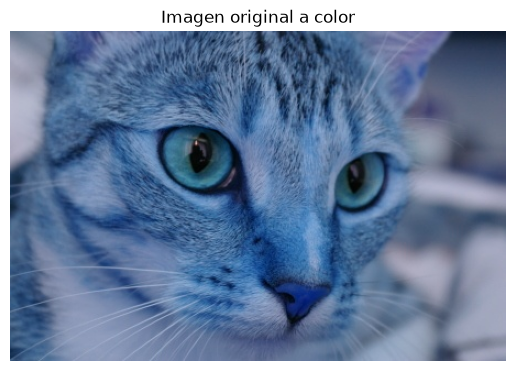

In [73]:
imagen = cv2.imread("gato.jpg")
plt.imshow(imagen)
plt.axis('off')
plt.title("Imagen original a color")

### Ejercicio 3.2
Existen dos formas de corregirlo:

* `img[:, :, ::-1]` → invierte el orden de los canales (**cambia la representación**)
* `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` → **cambia el espacio de color**

Apliquen ambas y verifiquen si el resultado numérico es idéntico.

(np.float64(-0.5), np.float64(450.5), np.float64(299.5), np.float64(-0.5))

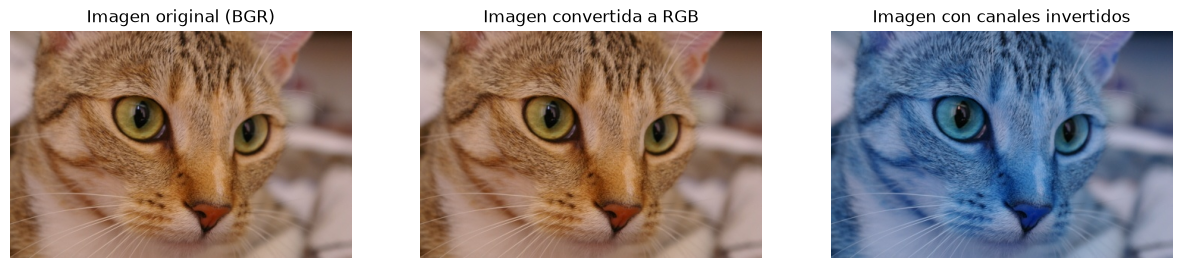

In [81]:
copia = imagen.copy()
imagen1 = cv2.cvtColor(copia, cv2.COLOR_BGR2RGB, copia) # Convertir de BGR a RGB
imagen2 = copia[:, :, ::-1]

subplot_titles = ["Imagen original (BGR)", "Imagen convertida a RGB", "Imagen con canales invertidos"]
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(copia); plt.title(subplot_titles[0]); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(imagen1); plt.title(subplot_titles[1]); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(imagen2); plt.title(subplot_titles[2]); plt.axis("off")

**Pregunta 3.2:** si el resultado numérico es el mismo, ¿cuál es la diferencia
conceptual entre las dos operaciones? ¿Cuál usarían dentro de un pipeline de procesamiento
y cuál solo para mostrar una figura?

---
## 4. Separación de canales

* `cv2.split(img)` **separa** la imagen en sus canales.
* `cv2.merge((c1, c2, c3))` los **une** nuevamente.

Recuerden el orden de OpenCV: `b, g, r = cv2.split(img)`.

### Ejercicio 4.1
Separen los canales de `ecuador2006.jpg` y muéstrenlos en escala de grises con su barra de color.

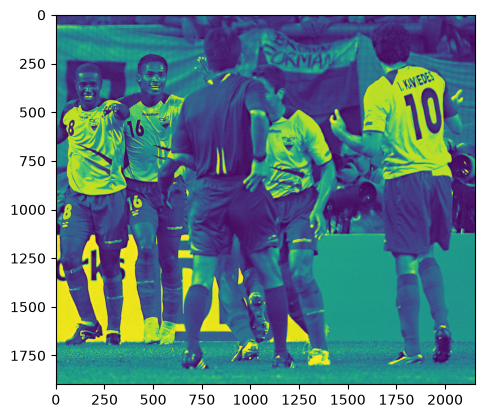

In [65]:
imagen2 = cv2.imread("ecuador2006.jpg",0)
plt.imshow(imagen2)

**Pregunta 4.1:** las camisetas amarillas se ven **claras** en el canal rojo y en el
verde, pero **oscuras** en el azul. ¿Por qué? ¿Y los pantalones azules?

### Ejercicio 4.2
Reconstruyan la imagen con `cv2.merge`. Prueben primero con el orden equivocado.

### Ejercicio 4.3
Anulen dos canales y dejen solo uno, como en la clase: separar, multiplicar por 0 los dos
canales descartados y volver a unir.

---
## 5. Distribución de intensidad: histogramas

El histograma cuenta **cuántos píxeles hay de cada intensidad**. Nos dice si la imagen es
oscura, clara, de bajo contraste, o si hay regiones bien diferenciadas.

`cv2.calcHist([imagen], [canal], máscara, [bins], [rango])`

### Ejercicio 5.1
Calculen y grafiquen el histograma de `gato.jpg` en escala de grises.

### Ejercicio 5.2
El mismo histograma se puede calcular con NumPy. Verifiquen que ambos coinciden.

### Ejercicio 5.3
Comparen la imagen original con su versión subexpuesta (`gato_oscuro.jpg`). Sin mirar las
fotos, ¿podrían decir cuál es cuál solo con el histograma?

### Ejercicio 5.4
Grafiquen los tres histogramas de color de `ecuador2006.jpg` en un mismo gráfico.

### Ejercicio 5.5 — Histograma con máscara

El tercer parámetro de `calcHist` es una **máscara**: solo se cuentan los píxeles donde la
máscara vale 255. Calculen el histograma de una región rectangular del césped y compárenlo
con el de la imagen completa.

---
## 6. ¿Cómo se forma la imagen a escala de grises?

**No basta con promediar.** El ojo humano es más sensible al verde, luego al rojo y mucho
menos al azul. Por eso la conversión usa la *luma*:

$$Y = 0{,}299\,R + 0{,}587\,G + 0{,}114\,B$$

### Ejercicio 6.1
Construyan la bandera RGB de la clase y conviértanla a escala de grises. Antes de ejecutar:
¿cuál de las tres franjas debería verse más clara?

### Ejercicio 6.2
Comparen dos conversiones: el **promedio simple** de los canales y `cv2.cvtColor`.

Ojo: la bandera está construida en orden **RGB**, así que para usar `COLOR_BGR2GRAY`
debemos entregarle la imagen en BGR.

---
# 7. Segmentación por color: un canal y un umbral

**Segmentar** es separar los píxeles que pertenecen a un objeto de los que pertenecen al
fondo. La estrategia más simple tiene cuatro pasos:

1. **Elegir el canal** en el que el objeto se distingue mejor del resto.
2. **Mirar el histograma** de ese canal: si es *bimodal* (dos "montañas"), el valle entre
   ellas es un buen **umbral**.
3. **Binarizar** con `cv2.threshold`: 255 donde se cumple la condición, 0 en el resto.
4. **Aplicar** la máscara sobre la imagen original.

En esta sección trabajaremos solo con **un canal a la vez**, para entender hasta dónde
llega esa idea y dónde se rompe.




### Ejercicio 7.1. Binarización: el cielo de Paseo Bulnes

`cv2.threshold(imagen, umbral, valor_max, tipo)` devuelve dos cosas: el umbral usado y la
imagen binaria.

* `cv2.THRESH_BINARY`: 255 si el píxel **supera** el umbral.
* `cv2.THRESH_BINARY_INV`: 255 si el píxel **está por debajo** del umbral.

El cielo es el caso ideal: es lo único fuertemente azul de la escena, así que el canal azul
por sí solo lo separa.

In [25]:
# parte 1

La máscara sola no es el resultado final: hay que **aplicarla**. `cv2.bitwise_and(img, img,
mask=m)` conserva la imagen donde la máscara vale 255 y deja negro el resto.

In [26]:
# parte 2

### Ejercicio 7.2. Un canal no aísla un color, aísla una familia de colores

Volvamos a los loros. Si binarizamos el canal azul esperando quedarnos con "el loro azul",
el resultado es otro: entra todo lo que tenga azul alto.

### Ejercicio 7.3. Elegir el umbral: mirar el histograma, no adivinar

La imagen `zebra.jpg` en escala de grises tiene tres poblaciones muy distintas: las franjas
negras, el pasto seco y las franjas blancas. Prueben tres umbrales y ubíquenlos sobre el
histograma.

### Ejercicio 7.4. Otsu: el umbral automático y sus supuestos

`cv2.THRESH_OTSU` elige el umbral solo, buscando el valor que mejor separa el histograma en
**dos** clases. Cuando la imagen efectivamente tiene dos poblaciones, acierta. Cuando tiene
tres, el resultado depende de cuál sea la más numerosa.

---
# 8. Operaciones entre canales

Un canal responde "cuánta luz roja, verde o azul hay". Un color, en cambio, es una
**relación** entre canales: el amarillo es rojo alto **y** verde alto **y** azul bajo. Por
eso, en vez de umbralizar un canal, conviene construir primero un **canal sintético** (un
índice) que exprese esa relación, y umbralizar ese.

Dos advertencias antes de programar:

* Los canales son `uint8`, así que una resta puede quedar negativa y **envolver**
  (recuerden el ejercicio 2.3). Hay que convertir a `int16` antes de restar y volver a
  `uint8` con `np.clip` después.
* El índice se elige a partir de la tabla de medianas, no por intuición.

### Ejercicio 8.1. Índice de amarillez: aislar un solo loro

Para el amarillo, la relación es: los dos canales altos son R y G, y el que debe ser bajo
es B. Eso se escribe como `min(R, G) - B`, que es grande solo si **ambos** son altos y el
azul es bajo.

### Ejercicio 8.2. Índice de madurez: el tomate rojo entre los verdes

En `tomates.png` todos los objetos son brillantes y el fondo también es claro, así que
ningún canal por separado sirve. Pero lo que distingue al tomate maduro es que su rojo
supera a su verde: `R - G`.

### Ejercicio 8.3. Las camisetas de la selección, y la limpieza de la máscara

Apliquen el índice de amarillez a `ecuador2006.jpg`. La máscara cruda siempre trae ruido:
píxeles sueltos por el pasto iluminado y agujeros dentro de las camisetas por los números y
los pliegues. Se corrigen con operaciones morfológicas:

* **Apertura** (`MORPH_OPEN`): erosión seguida de dilatación, elimina puntos sueltos.
* **Cierre** (`MORPH_CLOSE`): dilatación seguida de erosión, rellena agujeros pequeños.

**Pregunta 8.3.** Además de las camisetas quedaron seleccionados unos objetos pequeños
cerca del suelo. Miren la imagen original: ¿qué son? ¿Es un error del método o el método
está haciendo exactamente lo que le pedimos?

---
# 9. Croma: cambiar el fondo de una imagen

El croma (*chroma key*) es la aplicación más conocida de la segmentación por color: se graba
al sujeto delante de un fondo de color uniforme, se segmenta ese color y se reemplaza por
otra imagen.

Se usa verde (o azul) porque es el color **más lejano al tono de la piel humana**: así el
sujeto nunca se confunde con el fondo. Si el presentador usara una corbata verde,
desaparecería.

Vamos a poner a Marty (`marty.jpg`, con fondo verde) en el Paseo Bulnes.

### Ejercicio 9.1. Ajustar el fondo al tamaño del sujeto

Para combinar dos imágenes con operaciones de píxel, **ambas deben tener exactamente la
misma forma**. Como las proporciones no coinciden, se escala el fondo hasta cubrir y luego
se recorta el centro, en vez de deformarlo con un `resize` directo.

### Ejercicio 9.2. La máscara del fondo verde

El índice para el verde es simétrico al de amarillez: `G - max(R, B)`, es decir, cuánto
supera el verde al más alto de los otros dos. En un croma bien iluminado el histograma
resultante es el más bimodal que van a ver.

### Ejercicio 9.3. La composición

Con las dos máscaras complementarias, la composición es una suma: el sujeto donde vale su
máscara, el fondo nuevo donde vale la otra.